In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("data\\train.csv")
test_df = pd.read_csv("data\\test.csv")

,Unnamed: 0,full_name,label
0,507706,quail creek crossing,0
1,225326,lyn t ward,1
2,141944,the governors,0
3,404422,briteverify,0
4,258567,u.s. american,0
...,...,...,...
38310,228830,thomas russo,1
38311,336128,colorado democratic party,0
38312,300745,andreini-brophy anna,1
38313,425221,jill blair,1


In [3]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

y_train = train_df['label']
y_test = test_df['label']

In [4]:
X_test.shape, X_train.shape

((38315, 50669), (114945, 50669))

In [5]:
svc = svm.SVC(random_state=42)
svc.fit(X_train, y_train)
predicted_y = svc.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, predicted_y) * 100

recall = recall_score(y_test, predicted_y) * 100

precision = precision_score(y_test, predicted_y) * 100

f1= f1_score(y_test, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_test, predicted_y))

Accuracy: 90.59115229022576
Recall: 96.04384133611691
Precision: 86.6017224339969
f1_score: 91.0787200871093

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     19155
           1       0.87      0.96      0.91     19160

    accuracy                           0.91     38315
   macro avg       0.91      0.91      0.91     38315
weighted avg       0.91      0.91      0.91     38315



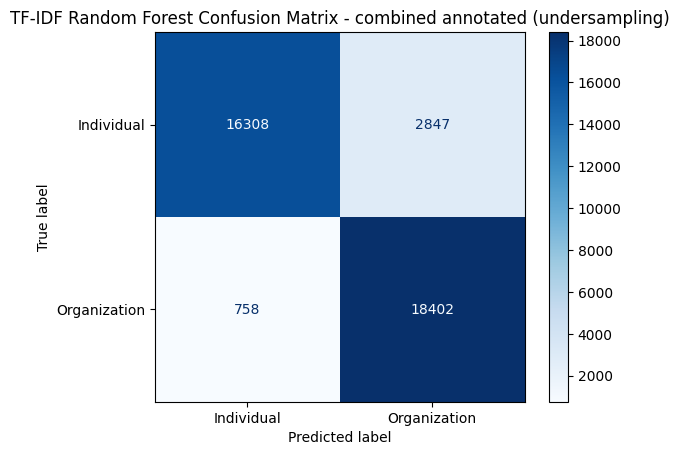

In [7]:
cm = confusion_matrix(y_test, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling)")
#plt.savefig('TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling).png', transparent=True, bbox_inches = 'tight')
plt.show()

In [ ]:
y_val

165237    1
355852    0
133935    0
72445     0
347253    1
         ..
402586    1
138432    0
228735    0
312170    1
226870    1
Name: label, Length: 38315, dtype: int64

In [ ]:
misclassified = np.where(y_val != predicted_y)[0]
misclassified


array([    9,    25,    88, ..., 38293, 38304, 38307], shape=(3663,))

In [ ]:
y_val_df = y_val.reset_index().copy()
y_val_df

,index,label
0,165237,1
1,355852,0
2,133935,0
3,72445,0
4,347253,1
...,...,...
38310,402586,1
38311,138432,0
38312,228735,0
38313,312170,1


In [ ]:

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_val_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Committee = 0
# Individual = 1

Number of misclassified samples: 3663
ctr: 0
Index: 9
Full Name: 800 got junk
True Label: 0, Predicted: 1
---
ctr: 1
Index: 25
Full Name: roger zener
True Label: 0, Predicted: 1
---
ctr: 2
Index: 88
Full Name: blevins may
True Label: 0, Predicted: 1
---
ctr: 3
Index: 90
Full Name: annette williams
True Label: 0, Predicted: 1
---
ctr: 4
Index: 120
Full Name: brooke sherrill
True Label: 0, Predicted: 1
---
ctr: 5
Index: 150
Full Name: green
True Label: 0, Predicted: 1
---
ctr: 6
Index: 165
Full Name: mike wood
True Label: 0, Predicted: 1
---
ctr: 7
Index: 169
Full Name: roessler steve
True Label: 0, Predicted: 1
---
ctr: 8
Index: 172
Full Name: avis brown davis
True Label: 1, Predicted: 0
---
ctr: 9
Index: 181
Full Name: bullock connie
True Label: 0, Predicted: 1
---
ctr: 10
Index: 204
Full Name: nancy reilly
True Label: 0, Predicted: 1
---
ctr: 11
Index: 207
Full Name: daryl reese
True Label: 0, Predicted: 1
---
ctr: 12
Index: 214
Full Name: dan lee
True Label: 0, Predicted: 1
---
ctr: 